In [ ]:
# https://github.com/berenslab/fundus_image_toolbox/issues/31

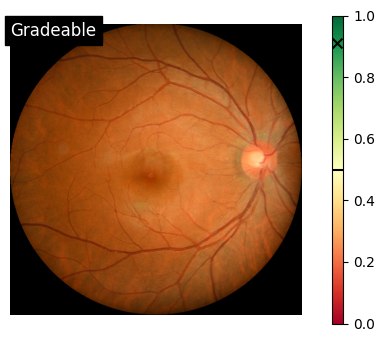

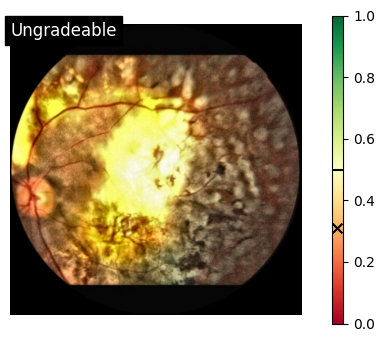

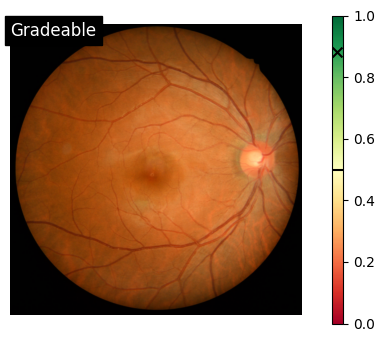

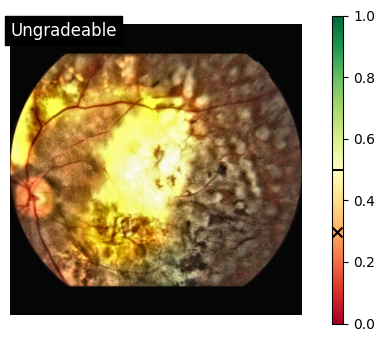

In [4]:
from PIL import Image
import torch
from torchvision import transforms as T
import fundus_image_toolbox as fit

# Resize smallest edge and center-crop to 512, then convert to tensor
def preprocess(img):
    tfm = T.Compose([
        T.Resize(512),
        T.CenterCrop(512),
        T.functional.to_tensor
    ])
    return tfm(img)

good, bad = Image.open("good.png"), Image.open("bad.png")
good_circle_cropped, bad_circle_cropped = fit.crop(T.functional.to_tensor(good), size=512, to_numpy=False), fit.crop(T.functional.to_tensor(bad), size=512, to_numpy=False)
good_square_cropped, bad_square_cropped = preprocess(good), preprocess(bad)

all = [
    good_circle_cropped, 
    bad_circle_cropped, 
    good_square_cropped, 
    bad_square_cropped
]

all_tensor = torch.stack(all)

confs, labels = fit.ensemble_predict_quality(
    ensemble, all_tensor, threshold=0.5, img_size=512
)

print()
for img, conf, label in zip(all, confs, labels):
    fit.plot_quality(img, conf, label, threshold=0.5)

How does new behavior to accept differently sized batch elements affect scores?

In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
import torchvision.transforms as T

import fundus_image_toolbox as fit

# --- setup ---
THRESHOLD = 0.5
IMG_DIR = Path(".")  # good.png / bad.png 
IMAGE_PATHS = {
    "good": IMG_DIR / "good.png",
    "bad": IMG_DIR / "bad.png",
}
NAMES = list(IMAGE_PATHS.keys())
PATHS = [IMAGE_PATHS[n] for n in NAMES]

print("Raw PIL sizes:", {n: Image.open(IMAGE_PATHS[n]).size for n in NAMES})  # (W, H)

ensemble = fit.load_quality_ensemble(device="cuda:0")

# --- preprocessing variants ---
def preprocess_pil_first(img):
    """Your tnp.ipynb style: Resize -> CenterCrop -> ToTensor on PIL."""
    tfm = T.Compose([
        T.Resize(512),
        T.CenterCrop(512),
        T.ToTensor(),
    ])
    return tfm(img)

def preprocess_tensor_first(img):
    """Model test order (without Normalize; FIT adds that internally)."""
    tfm = T.Compose([
        T.ToTensor(),
        T.Resize(512, antialias=True),
        T.CenterCrop(512),
    ])
    return tfm(img)

PREPROCESS = {
    "none": lambda img: img,                      # keep PIL
    "pil_first": preprocess_pil_first,            # -> CHW tensor
    "tensor_first": preprocess_tensor_first,      # -> CHW tensor
}

def build_items(preprocess_key):
    """Per-image preprocessed representations + metadata."""
    pp = PREPROCESS[preprocess_key]
    items = {}
    for name, path in IMAGE_PATHS.items():
        pil = Image.open(path).convert("RGB")
        out = pp(pil)
        items[name] = {
            "path": str(path),
            "pil": pil,
            "tensor_chw": out if isinstance(out, torch.Tensor) else None,
        }
    return items

def predict_one(x):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        conf, label = fit.ensemble_predict_quality(
            ensemble, x, threshold=THRESHOLD, print_result=False
        )
    warn_msgs = [str(w.message) for w in caught]
    conf = float(np.asarray(conf).reshape(-1)[0]) if np.ndim(conf) else float(conf)
    label = int(np.asarray(label).reshape(-1)[0]) if np.ndim(label) else int(label)
    return conf, label, warn_msgs

def predict_batch(x):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        conf, label = fit.ensemble_predict_quality(
            ensemble, x, threshold=THRESHOLD, print_result=False
        )
    warn_msgs = [str(w.message) for w in caught]
    conf = np.asarray(conf, dtype=float).reshape(-1)
    label = np.asarray(label, dtype=int).reshape(-1)
    return conf, label, warn_msgs

# --- delivery modes to test for each preprocess ---
def run_matrix(preprocess_key):
    items = build_items(preprocess_key)
    rows = []

    # 1) SINGLE paths (reference)
    for name in NAMES:
        conf, label, warns = predict_one(items[name]["path"])
        rows.append({
            "preprocess": preprocess_key,
            "mode": "single_path",
            "batch_input": "path",
            "image": name,
            "conf": conf,
            "label": label,
            "warn": " | ".join(warns) if warns else "",
        })

    # 2) SINGLE PIL
    for name in NAMES:
        conf, label, warns = predict_one(items[name]["pil"])
        rows.append({
            "preprocess": preprocess_key,
            "mode": "single_pil",
            "batch_input": "pil",
            "image": name,
            "conf": conf,
            "label": label,
            "warn": " | ".join(warns) if warns else "",
        })

    # 3) SINGLE CHW tensor (only if preprocessed)
    if preprocess_key != "none":
        for name in NAMES:
            conf, label, warns = predict_one(items[name]["tensor_chw"])
            rows.append({
                "preprocess": preprocess_key,
                "mode": "single_tensor_chw",
                "batch_input": "chw",
                "image": name,
                "conf": conf,
                "label": label,
                "warn": " | ".join(warns) if warns else "",
            })

    # 4) BATCH list paths
    confs, labels, warns = predict_batch([items[n]["path"] for n in NAMES])
    for i, name in enumerate(NAMES):
        rows.append({
            "preprocess": preprocess_key,
            "mode": "batch_list_paths",
            "batch_input": "list[path]",
            "image": name,
            "conf": confs[i],
            "label": labels[i],
            "warn": " | ".join(warns) if warns else "",
        })

    # 5) BATCH list PIL
    confs, labels, warns = predict_batch([items[n]["pil"] for n in NAMES])
    for i, name in enumerate(NAMES):
        rows.append({
            "preprocess": preprocess_key,
            "mode": "batch_list_pil",
            "batch_input": "list[pil]",
            "image": name,
            "conf": confs[i],
            "label": labels[i],
            "warn": " | ".join(warns) if warns else "",
        })

    # 6) BATCH list CHW tensors
    if preprocess_key != "none":
        chw_list = [items[n]["tensor_chw"] for n in NAMES]
        confs, labels, warns = predict_batch(chw_list)
        for i, name in enumerate(NAMES):
            rows.append({
                "preprocess": preprocess_key,
                "mode": "batch_list_chw",
                "batch_input": "list[chw]",
                "image": name,
                "conf": confs[i],
                "label": labels[i],
                "warn": " | ".join(warns) if warns else "",
            })

        # 7) BATCH stacked 4D tensor
        batch_4d = torch.stack(chw_list)  # (2, 3, 512, 512)
        confs, labels, warns = predict_batch(batch_4d)
        for i, name in enumerate(NAMES):
            rows.append({
                "preprocess": preprocess_key,
                "mode": "batch_4d_tensor",
                "batch_input": f"tensor{batch_4d.shape}",
                "image": name,
                "conf": confs[i],
                "label": labels[i],
                "warn": " | ".join(warns) if warns else "",
            })

    return pd.DataFrame(rows)

# --- run all preprocess variants ---
df = pd.concat([run_matrix(k) for k in PREPROCESS], ignore_index=True)

# pretty view
display(df.sort_values(["image", "preprocess", "mode"]).reset_index(drop=True))

# --- compare each batch mode against single-path reference ---
ref = (
    df[df["mode"] == "single_path"]
    .set_index(["preprocess", "image"])[["conf", "label"]]
    .rename(columns={"conf": "ref_conf", "label": "ref_label"})
)

batch_modes = [m for m in df["mode"].unique() if m.startswith("batch_")]
cmp = df[df["mode"].isin(batch_modes)].set_index(["preprocess", "mode", "image"])
cmp = cmp.join(ref, on=["preprocess", "image"])
cmp["d_conf"] = cmp["conf"] - cmp["ref_conf"]
cmp["label_match"] = cmp["label"] == cmp["ref_label"]

print("\nBatch vs single-path reference:")
display(
    cmp.reset_index()[
        ["preprocess", "mode", "image", "conf", "ref_conf", "d_conf", "label", "ref_label", "label_match", "warn"]
    ].sort_values(["image", "preprocess", "mode"])
)

# --- quick pivot: confidence by mode for each image/preprocess ---
pivot = df.pivot_table(
    index=["image", "preprocess"],
    columns="mode",
    values="conf",
    aggfunc="first",
)
display(pivot)

Raw PIL sizes: {'good': (2992, 2000), 'bad': (448, 448)}


[FIT:quality_prediction] Model loaded from 2024-05-03 14-38-34
[FIT:quality_prediction] Model loaded from 2024-05-03 14-25-19
[FIT:quality_prediction] Model loaded from 2024-05-03 14-25-42
[FIT:quality_prediction] Model loaded from 2024-05-03 14-58-37
[FIT:quality_prediction] Model loaded from 2024-05-03 16-23-29
[FIT:quality_prediction] Model loaded from 2024-05-03 15-28-00
[FIT:quality_prediction] Model loaded from 2024-05-03 15-04-29
[FIT:quality_prediction] Model loaded from 2024-05-06 20-25-14
[FIT:quality_prediction] Model loaded from 2024-05-03 15-52-56
[FIT:quality_prediction] Model loaded from 2024-05-03 15-59-31


,preprocess,mode,batch_input,image,conf,label,warn
0,none,batch_list_paths,list[path],bad,0.297465,0,[FIT:quality_prediction] Batch contains images...
1,none,batch_list_pil,list[pil],bad,0.297465,0,[FIT:quality_prediction] Batch contains images...
2,none,single_path,path,bad,0.297465,0,
3,none,single_pil,pil,bad,0.297465,0,
4,pil_first,batch_4d_tensor,"tensortorch.Size([2, 3, 512, 512])",bad,0.298657,0,
5,pil_first,batch_list_chw,list[chw],bad,0.298657,0,
6,pil_first,batch_list_paths,list[path],bad,0.297465,0,[FIT:quality_prediction] Batch contains images...
7,pil_first,batch_list_pil,list[pil],bad,0.297465,0,[FIT:quality_prediction] Batch contains images...
8,pil_first,single_path,path,bad,0.297465,0,
9,pil_first,single_pil,pil,bad,0.297465,0,



Batch vs single-path reference:


,preprocess,mode,image,conf,ref_conf,d_conf,label,ref_label,label_match,warn
1,none,batch_list_paths,bad,0.297465,0.297465,5.960464e-08,0,0,True,[FIT:quality_prediction] Batch contains images...
3,none,batch_list_pil,bad,0.297465,0.297465,5.960464e-08,0,0,True,[FIT:quality_prediction] Batch contains images...
11,pil_first,batch_4d_tensor,bad,0.298657,0.297465,1.192451e-03,0,0,True,
9,pil_first,batch_list_chw,bad,0.298657,0.297465,1.192451e-03,0,0,True,
5,pil_first,batch_list_paths,bad,0.297465,0.297465,5.960464e-08,0,0,True,[FIT:quality_prediction] Batch contains images...
7,pil_first,batch_list_pil,bad,0.297465,0.297465,5.960464e-08,0,0,True,[FIT:quality_prediction] Batch contains images...
19,tensor_first,batch_4d_tensor,bad,0.298528,0.297465,1.062751e-03,0,0,True,
17,tensor_first,batch_list_chw,bad,0.298528,0.297465,1.062751e-03,0,0,True,
13,tensor_first,batch_list_paths,bad,0.297465,0.297465,5.960464e-08,0,0,True,[FIT:quality_prediction] Batch contains images...
15,tensor_first,batch_list_pil,bad,0.297465,0.297465,5.960464e-08,0,0,True,[FIT:quality_prediction] Batch contains images...


mode                batch_4d_tensor  batch_list_chw  batch_list_paths  \
image preprocess                                                        
bad   none                      NaN             NaN          0.297465   
      pil_first            0.298657        0.298657          0.297465   
      tensor_first         0.298528        0.298528          0.297465   
good  none                      NaN             NaN          0.832330   
      pil_first            0.881784        0.881784          0.832330   
      tensor_first         0.879802        0.879802          0.832330   

mode                batch_list_pil  single_path  single_pil  single_tensor_chw  
image preprocess                                                                
bad   none                0.297465     0.297465    0.297465                NaN  
      pil_first           0.297465     0.297465    0.297465           0.298657  
      tensor_first        0.297465     0.297465    0.297465           0.298528  
good  none                0.832330     0.880579    0.880579                NaN  
      pil_first           0.832330     0.880579    0.880579           0.881784  
      tensor_first        0.832330     0.880579    0.880579           0.879802

In [7]:
from IPython.display import display, Markdown

def print_markdown_table(df):
    # fallback: use DataFrame's to_string as a pseudo-markdown code block
    md = "```\n" + df.to_string() + "\n```"
    display(Markdown(md))

print_markdown_table(pivot)

```
mode                batch_4d_tensor  batch_list_chw  batch_list_paths  batch_list_pil  single_path  single_pil  single_tensor_chw
image preprocess                                                                                                                 
bad   none                      NaN             NaN          0.297465        0.297465     0.297465    0.297465                NaN
      pil_first            0.298657        0.298657          0.297465        0.297465     0.297465    0.297465           0.298657
      tensor_first         0.298528        0.298528          0.297465        0.297465     0.297465    0.297465           0.298528
good  none                      NaN             NaN          0.832330        0.832330     0.880579    0.880579                NaN
      pil_first            0.881784        0.881784          0.832330        0.832330     0.880579    0.880579           0.881784
      tensor_first         0.879802        0.879802          0.832330        0.832330     0.880579    0.880579           0.879802
```